In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("/content/heart_disease_data.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


In [3]:
#data preprocessing
df = df.rename(columns={'age': 'age','sex': 'gender','cp': 'chest_pain_type',
                        'trestbps': 'resting_blood_pressure','chol': 'serum_cholesterol',
                        'fbs': 'fasting_blood_sugar','restecg': 'resting_ecg_results',
                        'thalach': 'maximum_heart_rate','exang': 'exercise_induced_angina',
                        'oldpeak': 'st_depression','slope': 'st_segment_slope',
                        'ca': 'number_of_major_vessels','thal': 'thalassemia_type',
                        'target': 'heart_disease'})
df.head()

,age,gender,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate,exercise_induced_angina,st_depression,st_segment_slope,number_of_major_vessels,thalassemia_type,heart_disease
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


In [4]:
df.isnull().sum() #no missing values

,0
age,0
gender,0
chest_pain_type,0
resting_blood_pressure,0
serum_cholesterol,0
fasting_blood_sugar,0
resting_ecg_results,0
maximum_heart_rate,0
exercise_induced_angina,0
st_depression,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      606 non-null    int64  
 1   gender                   606 non-null    int64  
 2   chest_pain_type          606 non-null    int64  
 3   resting_blood_pressure   606 non-null    int64  
 4   serum_cholesterol        606 non-null    int64  
 5   fasting_blood_sugar      606 non-null    int64  
 6   resting_ecg_results      606 non-null    int64  
 7   maximum_heart_rate       606 non-null    int64  
 8   exercise_induced_angina  606 non-null    int64  
 9   st_depression            606 non-null    float64
 10  st_segment_slope         606 non-null    int64  
 11  number_of_major_vessels  606 non-null    int64  
 12  thalassemia_type         606 non-null    int64  
 13  heart_disease            606 non-null    int64  
dtypes: float64(1), int64(13)
m

In [6]:
#separating features and target variable
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [7]:
#one hot encoding - categorical columns
X = pd.get_dummies(X, columns=['chest_pain_type','resting_ecg_results','st_segment_slope',
    'thalassemia_type'], drop_first=True)

In [8]:
#feature scaling since isolation forest works better with scaled data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
print("Original shape:", df.shape)
print("After encoding:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (606, 14)
After encoding: (606, 19)
Scaled shape: (606, 19)


In [10]:
#implementing isolation forest algorithm for anomaly detection
from sklearn.ensemble import IsolationForest
iso_model = IsolationForest(contamination=0.1, random_state=42)
iso_model.fit(X_scaled)

IsolationForest(contamination=0.1, random_state=42)

In [11]:
anomaly_preds = iso_model.predict(X_scaled)
print(anomaly_preds)

[ 1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1 -1  1  1  1 -1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1 -1
  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1

In [12]:
anomaly_prediction = [1 if x == -1 else 0 for x in anomaly_preds]
anomaly_prediction

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,


In [13]:
print(np.unique(anomaly_prediction, return_counts=True))

(array([0, 1]), array([546,  60]))


In [14]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y, anomaly_prediction)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y, anomaly_prediction))

accuracy = accuracy_score(y, anomaly_prediction)
print("\nAccuracy:", accuracy)

Confusion Matrix:
 [[242  34]
 [304  26]]

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.88      0.59       276
           1       0.43      0.08      0.13       330

    accuracy                           0.44       606
   macro avg       0.44      0.48      0.36       606
weighted avg       0.44      0.44      0.34       606


Accuracy: 0.44224422442244227


The confusion matrix compares the anomaly predictions generated by the Isolation Forest model with the actual heart

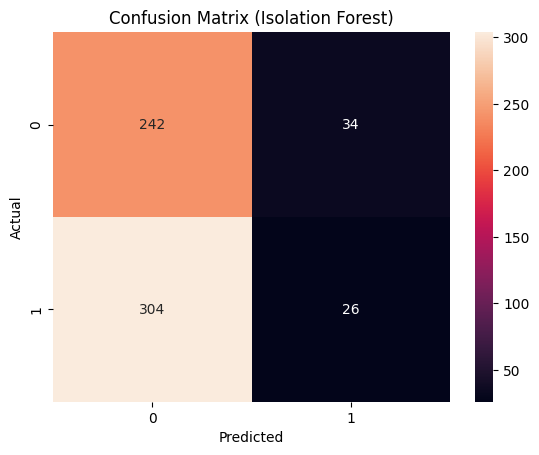

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Isolation Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The bar chart illustrates the distribution of predicted anomalies and normal cases, confirming that the model identifies approximately 10% of the data as high-risk based on the contamination parameter.

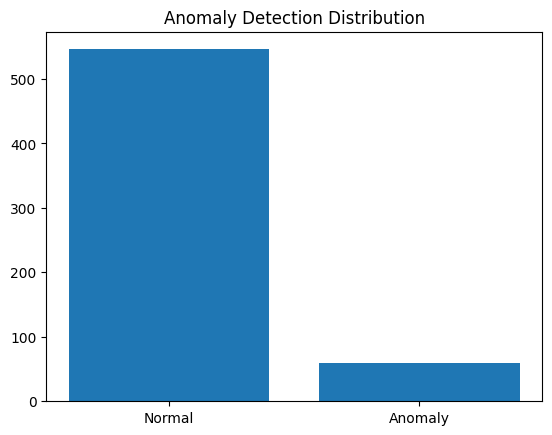

In [16]:
values, counts = np.unique(anomaly_prediction, return_counts=True)
plt.bar(['Normal', 'Anomaly'], counts)
plt.title("Anomaly Detection Distribution")
plt.show()

This plot shows how anomalies are distributed across age and cholesterol, highlighting that high-risk patients tend to lie outside the normal cluster

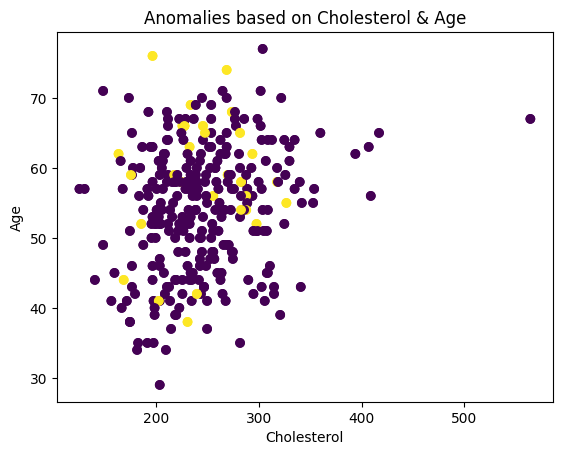

In [17]:
plt.scatter(df['serum_cholesterol'], df['age'], c=anomaly_prediction)
plt.xlabel("Cholesterol")
plt.ylabel("Age")
plt.title("Anomalies based on Cholesterol & Age")
plt.show()

This plot shows the distribution of cholesterol levels, helping identify normal ranges and potential outliers

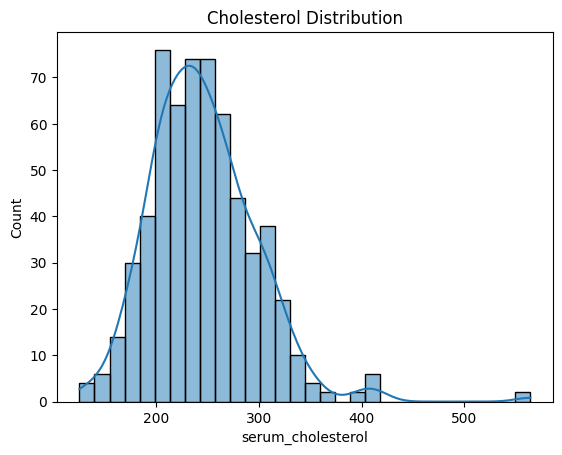

In [18]:
sns.histplot(df['serum_cholesterol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

In [19]:
#implementing supervised learning - logistic regression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [21]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm_lr = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm_lr)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[40 10]
 [ 7 65]]

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.80      0.82        50
           1       0.87      0.90      0.88        72

    accuracy                           0.86       122
   macro avg       0.86      0.85      0.85       122
weighted avg       0.86      0.86      0.86       122


Accuracy: 0.860655737704918


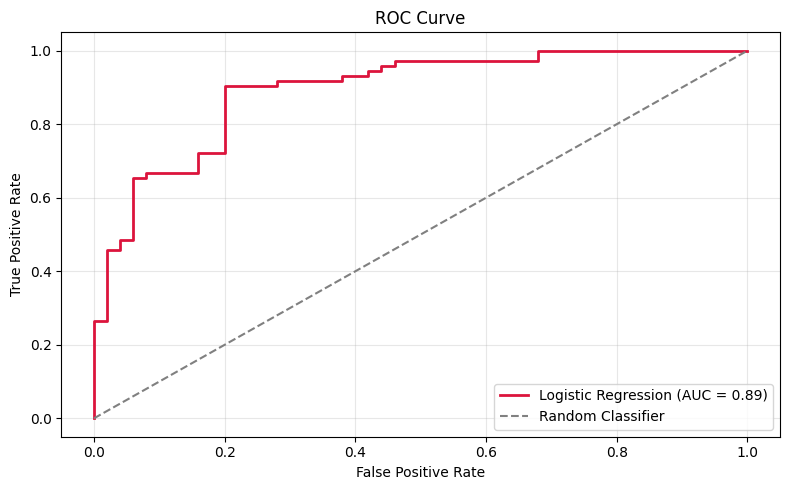

AUC Score: 0.8925


In [24]:
# ROC Curve - Logistic Regression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

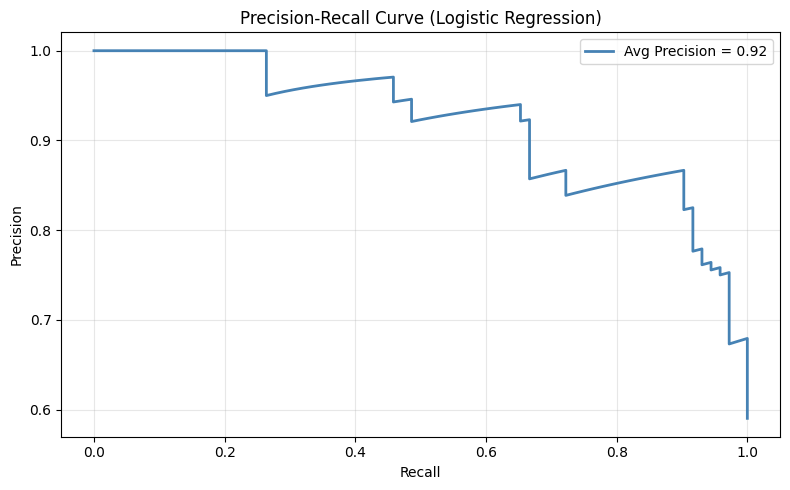

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Logistic Regression)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

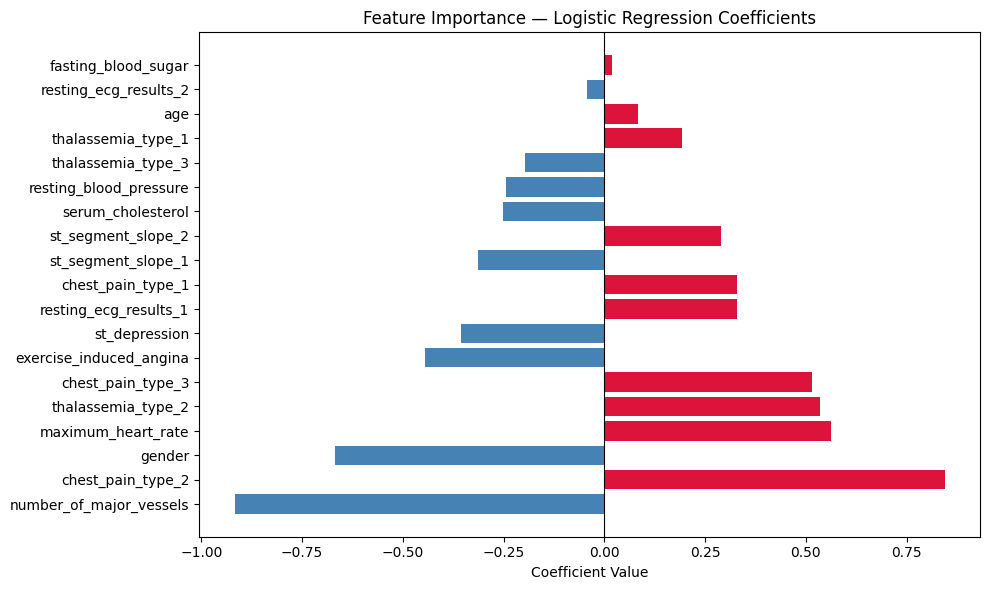

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance — Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

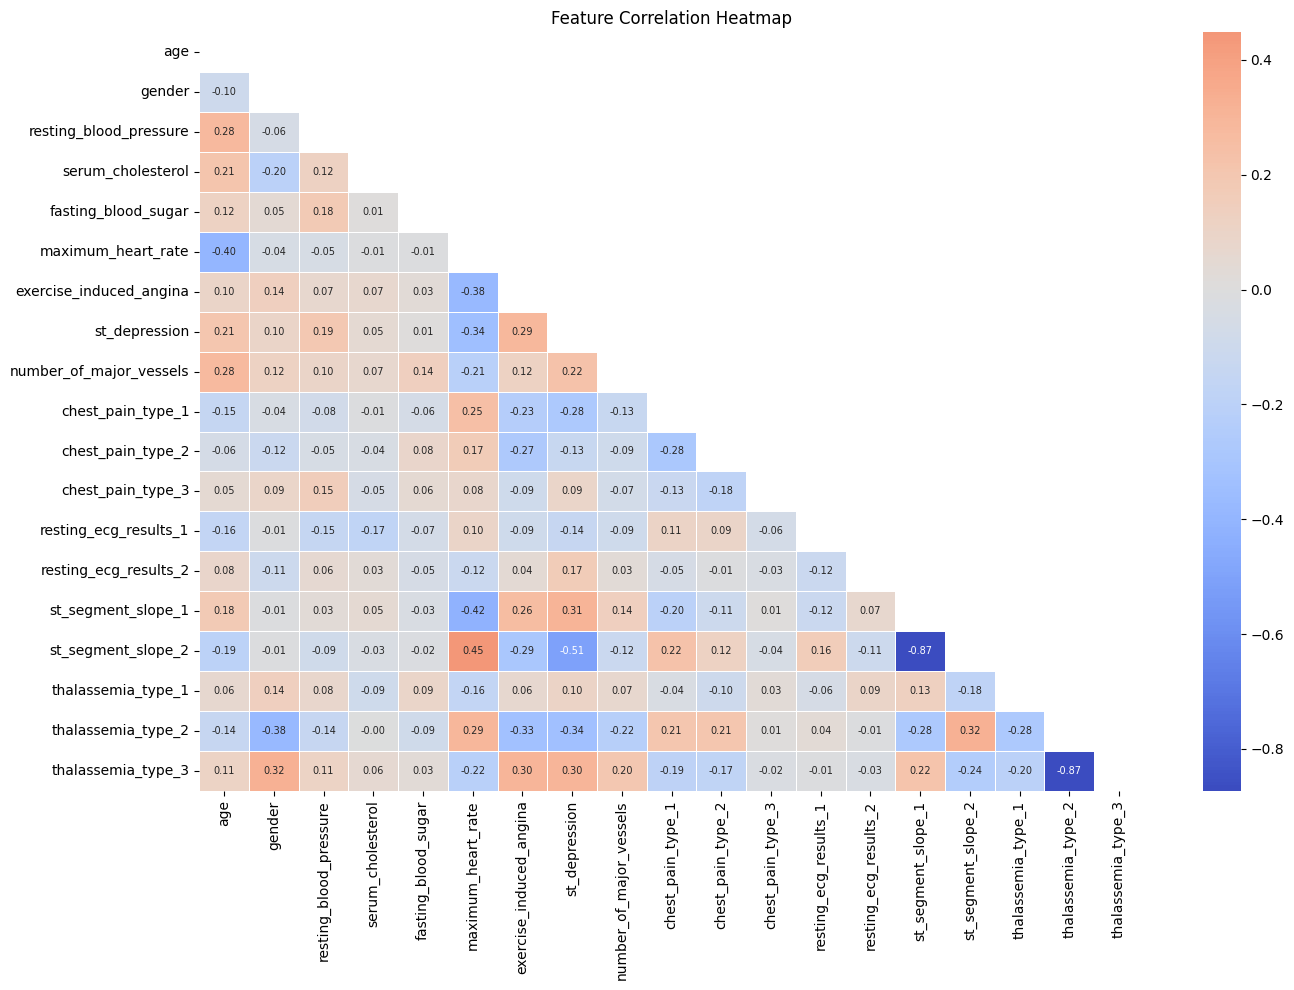

In [27]:
import seaborn as sns

plt.figure(figsize=(14, 10))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

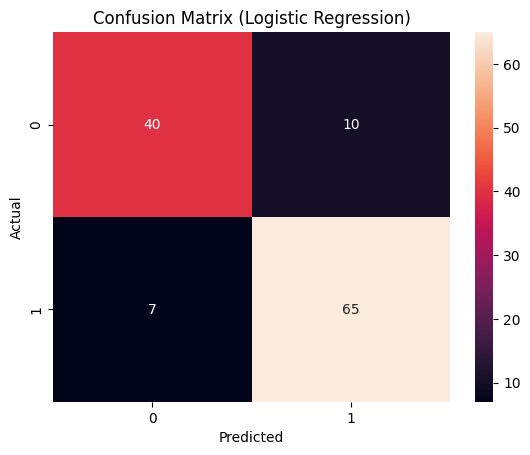

In [23]:
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
import joblib

# Save the trained models and scaler
joblib.dump(model, 'logistic_model.pkl')
joblib.dump(iso_model, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature column names (needed for prediction)
import json
with open('feature_columns.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print("Models saved successfully!")
print("Files created: logistic_model.pkl, isolation_forest_model.pkl, scaler.pkl, feature_columns.json")

Models saved successfully!
Files created: logistic_model.pkl, isolation_forest_model.pkl, scaler.pkl, feature_columns.json
